In [ ]:
import math
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
import numpy as np

np.random.seed(42)

korpus = [
    "Hayvancılık yapan genç kız üniversiteden birincilikle mezun oldu",
    "Soğan doğrarken gözlerin yaşarmasına neden olan sorunun çözümü sanılandan daha basit olabilir. Yeni bir araştırmaya göre, keskin bir bıçak kullanmak ve soğanı yavaş hareketlerle doğramak, havaya yayılan tahriş edici damlacıkların miktarını önemli ölçüde azaltıyor. Bilim insanları, soğan kesildiğinde hücrelerin parçalanmasıyla ortaya çıkan ve gözleri yakan kimyasalın küçük sıvı damlacıklarıyla havaya karıştığını belirledi. Yapılan deneylerde, kör bıçaklarla hızlı kesimlerin çok daha fazla sıvı püskürttüğü, keskin bıçaklarla yapılan yavaş kesimlerde ise damlacıkların göz seviyesine dahi ulaşamadığı görüldü. Araştırmacılar, bulguların yalnızca mutfakta göz yaşlarını azaltmakla kalmayıp, havada taşınan parçacıkların ve bazı mikroorganizmaların yayılımını anlamaya da katkı sağlayabileceğini ifade ediyor.",
    "Küresel piyasalarda jeopolitik risklerin tırmanması ve merkez bankalarının faiz politikalarına ilişkin belirsizlikler, değerli metaller üzerinde sert bir baskı oluşturmaya devam ediyor. Yılın ilk aylarında üst üste tarihi zirvelerini yenileyen altın piyasası, son dört aydır adeta nefes kesen bir geri çekilme sürecinin içerisine girdi. Piyasalardaki bu dalgalı seyir ve belirsizlik devam ederken, yatırımcıların yakından takip ettiği Altın ve Para Piyasaları Uzmanı İslam Memiş, piyasaların geleceğine ışık tutacak çarpıcı açıklamalarda bulundu.",

]

def tokenize(text):
    return text.lower().split()

tokenize_korpus = [tokenize(doc) for doc in korpus]
kelimeler = sorted(set(w for doc in tokenize_korpus for w in doc))
kelime_idx = {w: i for i, w in enumerate(kelimeler)}
idx_kelime = {i: w for w, i in kelime_idx.items()}
V = len(tokenize_korpus)

print(f"Kelime dağarcığı boyutu (V): {V}")
print(f"Kelimeler: {tokenize_korpus}")


Kelime dağarcığı boyutu (V): 3
Kelimeler: [['hayvancılık', 'yapan', 'genç', 'kız', 'üniversiteden', 'birincilikle', 'mezun', 'oldu'], ['soğan', 'doğrarken', 'gözlerin', 'yaşarmasına', 'neden', 'olan', 'sorunun', 'çözümü', 'sanılandan', 'daha', 'basit', 'olabilir.', 'yeni', 'bir', 'araştırmaya', 'göre,', 'keskin', 'bir', 'bıçak', 'kullanmak', 've', 'soğanı', 'yavaş', 'hareketlerle', 'doğramak,', 'havaya', 'yayılan', 'tahriş', 'edici', 'damlacıkların', 'miktarını', 'önemli', 'ölçüde', 'azaltıyor.', 'bilim', 'insanları,', 'soğan', 'kesildiğinde', 'hücrelerin', 'parçalanmasıyla', 'ortaya', 'çıkan', 've', 'gözleri', 'yakan', 'kimyasalın', 'küçük', 'sıvı', 'damlacıklarıyla', 'havaya', 'karıştığını', 'belirledi.', 'yapılan', 'deneylerde,', 'kör', 'bıçaklarla', 'hızlı', 'kesimlerin', 'çok', 'daha', 'fazla', 'sıvı', 'püskürttüğü,', 'keskin', 'bıçaklarla', 'yapılan', 'yavaş', 'kesimlerde', 'ise', 'damlacıkların', 'göz', 'seviyesine', 'dahi', 'ulaşamadığı', 'görüldü.', 'araştırmacılar,', 'bulgula

In [ ]:
def get_word_contexts(tokenized_corpus, target_word, window_size=2):

    sonuclar = []

    for cumle_no, doc in enumerate(tokenized_corpus):

        for i, word in enumerate(doc):

            if word == target_word:

                bas = max(0, i - window_size)
                son = min(len(doc), i + window_size + 1)

                onceki = doc[bas:i]
                sonraki = doc[i+1:son]

                sonuclar.append({
                    "cumle_no": cumle_no,
                    "hedef_kelime": word,
                    "oncesi": onceki,
                    "sonrasi": sonraki
                })

    return sonuclar

In [ ]:
hedef_kelime = "altın"

sonuclar = get_word_contexts(
    tokenize_korpus,
    hedef_kelime,
    window_size=2
)

In [ ]:
print(f"Korpus boyutu: {len(korpus)} cumle")
print(f"Benzersiz kelime sayisi: {len(set(' '.join(korpus).split()))}")
for sonuc in sonuclar:

    print(f"Cümle No : {sonuc['cumle_no']}")
    print(f"Hedef    : {sonuc['hedef_kelime']}")
    print(f"Öncesi   : {sonuc['oncesi']}")
    print(f"Sonrası  : {sonuc['sonrasi']}")

Korpus boyutu: 3 cumle
Benzersiz kelime sayisi: 155
Cümle No : 2
Hedef    : altın
Öncesi   : ['zirvelerini', 'yenileyen']
Sonrası  : ['piyasası,', 'son']
Cümle No : 2
Hedef    : altın
Öncesi   : ['takip', 'ettiği']
Sonrası  : ['ve', 'para']


In [ ]:
def get_word2vec_contexts(tokenized_corpus,
                          target_word,
                          window_size=2):

    contexts = []

    for doc in tokenized_corpus:

        for i, word in enumerate(doc):

            if word == target_word:

                bas = max(0, i-window_size)
                son = min(len(doc), i+window_size+1)

                context = []

                for j in range(bas, son):

                    if j != i:
                        context.append(doc[j])

                contexts.append(context)

    return contexts

In [ ]:
contexts = get_word2vec_contexts(
    tokenize_korpus,
    "altın",
    window_size=2
)

print(contexts)

[['zirvelerini', 'yenileyen', 'piyasası,', 'son'], ['takip', 'ettiği', 've', 'para']]


In [ ]:
# Komşu (context) kelimeleri çıkarma
def get_context_pairs(tokenize_korpus, window_size=2):
    pairs = []
    for doc in tokenize_korpus:
        for i, hedef in enumerate(doc):
            # Pencere içindeki komşular
            bas = max(0, i - window_size)
            son = min(len(doc), i + window_size + 1)
            for j in range(bas, son):
                if i != j:
                    pairs.append((hedef, doc[j]))
    return pairs

context_pairs = get_context_pairs(tokenize_korpus, window_size=2)
print(f"Toplam (hedef, komşu) çifti: {len(context_pairs)}")
print("İlk 10 çift:")
for pair in context_pairs[:10]:
    print(f"  '{pair[0]}' -> '{pair[1]}'")

Toplam (hedef, komşu) çifti: 674
İlk 10 çift:
  'hayvancılık' -> 'yapan'
  'hayvancılık' -> 'genç'
  'yapan' -> 'hayvancılık'
  'yapan' -> 'genç'
  'yapan' -> 'kız'
  'genç' -> 'hayvancılık'
  'genç' -> 'yapan'
  'genç' -> 'kız'
  'genç' -> 'üniversiteden'
  'kız' -> 'yapan'


Birlikte Oluşum Matrisi (ilk 10 kelime):


,adeta,altın,anlamaya,"araştırmacılar,",araştırmaya,aydır,aylarında,azaltmakla,azaltıyor.,açıklamalarda
adeta,0,0,0,0,0,1,0,0,0,0
altın,0,0,0,0,0,0,0,0,0,0
anlamaya,0,0,0,0,0,0,0,0,0,0
"araştırmacılar,",0,0,0,0,0,0,0,0,0,0
araştırmaya,0,0,0,0,0,0,0,0,0,0
aydır,1,0,0,0,0,0,0,0,0,0
aylarında,0,0,0,0,0,0,0,0,0,0
azaltmakla,0,0,0,0,0,0,0,0,0,0
azaltıyor.,0,0,0,0,0,0,0,0,0,0
açıklamalarda,0,0,0,0,0,0,0,0,0,0


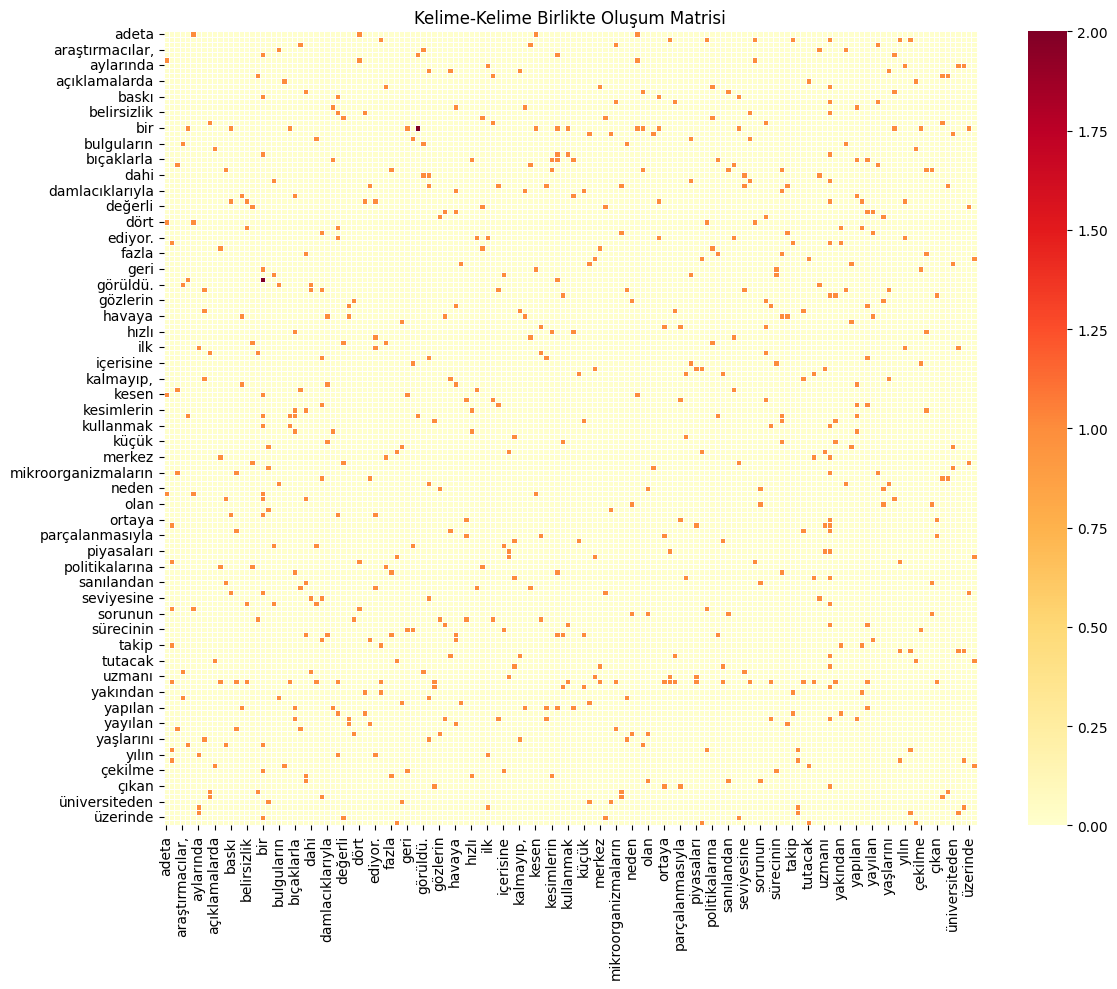

In [ ]:
# Birlikte oluşum matrisi
V = len(kelimeler) # V'yi kelime dağarcığı boyutuna göre yeniden tanımlayın
cooc = np.zeros((V, V), dtype=int)
for hedef, komşu in context_pairs:
    i, j = kelime_idx[hedef], kelime_idx[komşu]
    cooc[i, j] += 1

df_cooc = pd.DataFrame(cooc, index=kelimeler, columns=kelimeler)
print("Birlikte Oluşum Matrisi (ilk 10 kelime):")
display(df_cooc.iloc[:10, :10])

# Görselleştirme: Isı haritası
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_cooc, cmap="YlOrRd", annot=True if V < 15 else False, fmt="d", linewidths=0.5)
plt.title("Kelime-Kelime Birlikte Oluşum Matrisi")
plt.tight_layout()
plt.show()

